In [4]:
import pandas as pd    
df=pd.read_csv("/home/ayush/Documents/ML_Progress/AIML/sklearn/student_performance__data.csv")


print("sample rows")
print(df.head())


#df.shape	    Returns both rows and columns(20, 6)
#df.shape[0]	First element (rows)20
#df.shape[1]	Second element (columns)6

print("dataset shape")
print(f'Rows:{df.shape[0]},Columns:{df.shape[1]}')

print("Dataset info")
print(df.info)

print("summary of the data")
print(df.describe(include='all'))

print("finding the missing values")
print(df.isnull().sum())



sample rows
   StudyHours  Attendance  PastScore Internet  SleepHours Passed
0           2          60         40      Yes           5     No
1           5          80         60       No           6    Yes
2           8          90         75      Yes           8    Yes
3           3          70         50      Yes           5     No
4           7          85         70       No           7    Yes
dataset shape
Rows:20,Columns:6
Dataset info
<bound method DataFrame.info of     StudyHours  Attendance  PastScore Internet  SleepHours Passed
0            2          60         40      Yes           5     No
1            5          80         60       No           6    Yes
2            8          90         75      Yes           8    Yes
3            3          70         50      Yes           5     No
4            7          85         70       No           7    Yes
5            1          50         30       No           4     No
6            6          78         68      Yes           6 

In [4]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("/home/ayush/Documents/ML_Progress/AIML/sklearn/student_performance__data.csv")
print("Missing value in each column")
print(df.isnull().sum())

le = LabelEncoder()
df['Internet']=le.fit_transform(df["Internet"])
df['passes']=le.fit_transform(df["Passed"])
print("after encoding the data")
print(df.head())
print('data typer after cleaning')
print(df.dtypes)



Missing value in each column
StudyHours    0
Attendance    0
PastScore     0
Internet      0
SleepHours    0
Passed        0
dtype: int64
after encoding the data
   StudyHours  Attendance  PastScore  Internet  SleepHours Passed  passes
0           2          60         40         1           5     No       0
1           5          80         60         0           6    Yes       1
2           8          90         75         1           8    Yes       1
3           3          70         50         1           5     No       0
4           7          85         70         0           7    Yes       1
data typer after cleaning
StudyHours    int64
Attendance    int64
PastScore     int64
Internet      int64
SleepHours    int64
Passed          str
passes        int64
dtype: object


Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



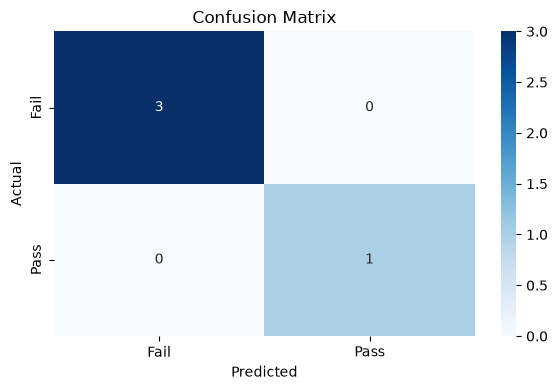


----- Predict Your Result -----

Prediction Based on Input: Pass


/home/ayush/Documents/ML_Progress/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("/home/ayush/Documents/ML_Progress/AIML/sklearn/student_performance__data.csv")

# Label Encoding
le = LabelEncoder()
df["Internet"] = le.fit_transform(df["Internet"])
df["Passed"] = le.fit_transform(df["Passed"])

# Feature Scaling
features = ["StudyHours", "Attendance", "PastScore", "SleepHours"]

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[features] = scaler.fit_transform(df_scaled[features])

# Features and Target
X = df_scaled[features]
y = df_scaled["Passed"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=40
)

# Train Model
model = LogisticRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Classification Report
print("Classification Report")
print(classification_report(y_test, y_pred))

# ---------------- Confusion Matrix ----------------

conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

# ---------------- User Prediction ----------------

print("\n----- Predict Your Result -----")

try:
    study_hours = float(input("Enter Study Hours: "))
    attendance = float(input("Enter Attendance: "))
    past_score = float(input("Enter Past Score: "))
    sleep_hours = float(input("Enter Sleep Hours: "))

    # Create DataFrame
    user_input_df = pd.DataFrame([{
        "StudyHours": study_hours,
        "Attendance": attendance,
        "PastScore": past_score,
        "SleepHours": sleep_hours
    }])

    # Scale user input
    user_input_scaled = scaler.transform(user_input_df)

    # Predict
    prediction = model.predict(user_input_scaled)

    # Display Result
    result = "Pass" if prediction[0] == 1 else "Fail"

    print(f"\nPrediction Based on Input: {result}")

except ValueError:
    print("Please enter only numeric values.")

except Exception as e:
    print("Error:", e)